# 7. PyTorch Tutorial 07 - Linear Regression

In [3]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

## 0) Prepare data

**The "random state" in sklearn datasets is used to make the data generation process reproducible. By passing a random state (an integer value), the data generated will always be the same, even if you run the code multiple times. This allows others to reproduce your results.**

When you call make_regression, a random dataset is generated based on the parameters you pass. By default, this is done using a random number generator with a random initial state. But by passing a random state, it initializes the random number generator with that state, causing it to generate the same "random" numbers, and thus the same dataset.

This allows others to exactly reproduce your results by generating the same dataset. Without a random state, running the code multiple times would generate different random datasets, leading to different results.

So in short, the "random state" in make_regression allows you to set the random seed, making the data generation deterministic and reproducible for others.

In [30]:
X_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)

In [31]:
X_numpy.dtype

dtype('float64')

In [32]:
X_numpy.reshape(-1)

array([-0.61175641, -0.24937038,  0.48851815,  0.76201118,  1.51981682,
        0.37756379,  0.51292982, -0.67124613, -1.39649634,  0.31563495,
       -0.63699565, -0.39675353, -1.10061918,  0.90085595, -1.09989127,
        0.82797464, -0.07557171, -0.35224985, -0.67066229, -1.07296862,
       -0.30620401,  2.18557541,  0.86540763,  0.19829972, -0.38405435,
       -0.68372786,  0.05080775,  0.58281521,  1.25286816, -0.75439794,
       -0.34934272, -0.88762896,  0.18656139,  0.87616892,  0.83898341,
       -0.50446586, -0.34385368,  1.6924546 , -2.3015387 ,  0.93110208,
        2.10025514,  1.46210794, -0.84520564, -0.87785842, -0.3224172 ,
        0.88514116,  0.16003707,  1.13162939, -0.37528495,  0.50249434,
       -0.20889423,  0.12015895,  0.58662319,  0.3190391 , -0.69166075,
        0.69803203,  1.19891788, -0.20075807,  0.53035547,  0.74204416,
        0.41005165,  0.11900865, -0.7612069 ,  0.42349435,  0.30017032,
       -1.1425182 ,  0.18515642, -0.93576943, -0.62000084, -1.11

## Cast to float Tensor

In [33]:
X = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))

# make columun vector
y = y.view(y.shape[0], 1)

n_samples, n_features = X.shape

In [34]:
X.dtype, X.shape

(torch.float32, torch.Size([100, 1]))

In [35]:
y.shape

torch.Size([100, 1])

## 1) Model

In [36]:
# Linear model f = wx + b
input_size = n_features
output_size = 1
model = nn.Linear(input_size, output_size)
model.parameters()

<generator object Module.parameters at 0x000002D32FEEB1B0>

## 2) Loss and optimizer

In [37]:
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) 

## 3) Training loop

In [38]:
num_epochs = 1000

for epoch in range(num_epochs):
    # Forward pass and loss
    y_predicted = model(X)
    loss = criterion(y_predicted, y)
    
    # Backward pass and update
    loss.backward()
    optimizer.step()

    # zero grad before new step
    optimizer.zero_grad()

    if (epoch+1) % 100 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

epoch: 100, loss = 564.1208
epoch: 200, loss = 342.5852
epoch: 300, loss = 333.0096
epoch: 400, loss = 332.5872
epoch: 500, loss = 332.5685
epoch: 600, loss = 332.5676
epoch: 700, loss = 332.5675
epoch: 800, loss = 332.5676
epoch: 900, loss = 332.5676
epoch: 1000, loss = 332.5676


In [39]:
model.parameters()

<generator object Module.parameters at 0x000002D32FEEB680>

## Plot

In [44]:
# .detach() sets the 'requises_grad' to False
predicted = model(X).detach()
predicted.requires_grad

False

In [45]:
# .numpy() casts a tensor to a np.ndarray
predicted = predicted.numpy()

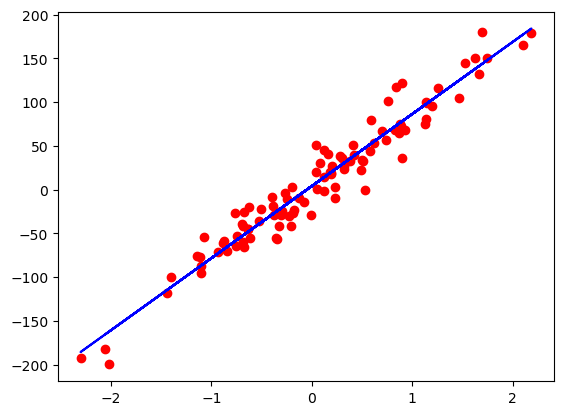

In [46]:
#plt.scatter(X_numpy, y_numpy, color='red')
plt.plot(X_numpy, y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()